<a href="https://colab.research.google.com/github/bigdatahub-ap/indonesia-workshop-on-use-of-ads/blob/main/notebooks/index_calculation_exercises_solutions_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
  import pyindexnum as pin
except:
  # Force a compatible numpy version first to avoid the 'numpy.rec' error in scipy
  !pip install "numpy>=1.26.4,<2.0.0" "scipy<1.14.0" --quiet
  !pip install pyindexnum --quiet
  import pyindexnum as pin

# Note: You may need to restart the session after running this cell
# (Runtime -> Restart session) and run this cell again to install the
# required versions of numpy and scipy.

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
import re

## Dataset

We use data from a set of food prices in Italian supermarkets provided by Banca d'Italia, Università Campus Bio-Medico and Università degli Studi della Tuscia. The complete dataset is available [here](https://zenodo.org/records/14927602). We aggregated the data by month and added artificial quantities.

> **Note:** Each row represents one product in one month, with its price and quantity sold.


In [ ]:
data_df = pd.read_csv("https://raw.githubusercontent.com/UN-Task-Team-for-Scanner-Data/alternative-data-sources-price-statistics/refs/heads/main/data/monthly_avg_price_with_qty.csv")

## Data Preparation

Before calculating indices we need to prepare the data carefully. Two main steps:

1. **Filter to a homogeneous set of products and stores.** Different regions or store types should not be mixed when calculating elementary indices, as price levels can differ systematically between them. We restrict to apples sold in store 3.

2. **Harmonise prices to a common unit.** Products come in different package sizes (e.g. 1 kg bag vs. 500 gr bag). To make prices comparable we convert all prices to price per kilogram and adjust quantities accordingly to keep expenditure consistent.

> **Important:** This adjustment affects the Dutot index, which uses arithmetic means of prices and is therefore sensitive to the unit of measurement.


In [ ]:
# 1. Filter for cured meat in Store 5 and cleanup columns
select_df = data_df[(data_df["COICOP5"] == "Packaged Cured Meats") & (data_df["store_id"] == 5)].copy()

# Create product_id based on factors, calculate volume, and drop columns
select_df['product_id'] = select_df['product'].astype('category').cat.codes
select_df['volume'] = select_df['price'] * select_df['quantity']
select_df = select_df.drop(columns=['total_quantity', 'quantity_share'])

In [ ]:
# 2. Extract package size from product description and convert to kg
def extract_size(row):
    product_desc = row['product']
    # Extract numeric value using regex (matches digits with optional decimal point)
    match = re.search(r"(\d+\.?\d*)", product_desc)
    if not match:
        return np.nan

    val = float(match.group(1))

    if product_desc.endswith("kg"):
        return val
    elif product_desc.endswith("gr"):
        return val / 1000
    return np.nan

select_df['size'] = select_df.apply(extract_size, axis=1)

# 3. Adjust price to per kg and quantity to kg sold
select_df['price'] = select_df['price'] / select_df['size']
select_df['quantity'] = select_df['quantity'] * select_df['size']

select_df.head()

,month_year,product,store_id,COICOP5,COICOP4,price,quantity,product_id,volume,size
1393,2020-12,aia aequilibrium bresaola tacchino 100.0 gr,5,Packaged Cured Meats,Meat,36.800000,10.926244,0,402.085773,0.1
1394,2021-01,aia aequilibrium bresaola tacchino 100.0 gr,5,Packaged Cured Meats,Meat,27.513333,12.867553,0,354.029273,0.1
1395,2021-04,aia aequilibrium bresaola tacchino 100.0 gr,5,Packaged Cured Meats,Meat,26.900000,11.940976,0,321.212267,0.1
1396,2021-05,aia aequilibrium bresaola tacchino 100.0 gr,5,Packaged Cured Meats,Meat,35.900000,9.892491,0,355.140441,0.1
1397,2021-07,aia aequilibrium bresaola tacchino 100.0 gr,5,Packaged Cured Meats,Meat,22.400000,12.737603,0,285.322303,0.1


We convert the dataframe into Polars, as this is the library used by PyIndexNum under the hood.

In [ ]:
select_pl = pl.from_pandas(select_df)
select_pl.head()

month_year,product,store_id,COICOP5,COICOP4,price,quantity,product_id,volume,size
str,str,i64,str,str,f64,f64,i8,f64,f64
"""2020-12""","""aia aequilibrium bresaola tacc…",5,"""Packaged Cured Meats""","""Meat""",36.8,10.926244,0,402.085773,0.1
"""2021-01""","""aia aequilibrium bresaola tacc…",5,"""Packaged Cured Meats""","""Meat""",27.513333,12.867553,0,354.029273,0.1
"""2021-04""","""aia aequilibrium bresaola tacc…",5,"""Packaged Cured Meats""","""Meat""",26.9,11.940976,0,321.212267,0.1
"""2021-05""","""aia aequilibrium bresaola tacc…",5,"""Packaged Cured Meats""","""Meat""",35.9,9.892491,0,355.140441,0.1
"""2021-07""","""aia aequilibrium bresaola tacc…",5,"""Packaged Cured Meats""","""Meat""",22.4,12.737603,0,285.322303,0.1


## Multilateral Price Indices

Unlike bilateral indices (which compare two periods directly), **multilateral indices** compare many periods simultaneously to satisfy the transitivity property (if index $I_{0,1}$ and $I_{1,2}$ are known, then $I_{0,2} = I_{0,1} \times I_{1,2}$). This is crucial for scanner data to avoid 'chain drift'.

### Data Preparation for pyindexnum
The `pyindexnum` library expects a specific format for the dataframe in order to perform index calculaktions. We will leverage the functions `standardize_columns` and `aggregate_time` for this.

In [ ]:
# Use pyindexnum utility to prepare the dataframe
# This function handles date conversion, sorting, and ensures no missing values
standard_pl = pin.utils.standardize_columns(
    df=select_pl,
    date_col='month_year',
    price_col='price',
    quantity_col='quantity',
    id_col='product_id',
    date_format='%Y-%m'
)

agg_pl = pin.utils.aggregate_time(
    df=standard_pl,
    quantity_col="quantity",
    agg_type="arithmetic",
    freq="1mo"
)



We select the first 13 months for the first window for index calculation, and another window shifted by 1 month for the index extension exercise.

In [ ]:
periods = sorted(agg_pl["period"].unique())

base_pl = agg_pl.filter(pl.col("period").is_in(periods[:13]))
extend_pl = agg_pl.filter(pl.col("period").is_in(periods[1:14]))

Most index formulas require balanced data. We will leverage the utility functions in PyIndexNum to create two different datasets:


1.   A dataset with only the product common across all periods
2.   Another dataset with carry forward imputation



In [ ]:
base_common_pl = pin.utils.remove_unbalanced(base_pl)
extend_common_pl = pin.utils.remove_unbalanced(extend_pl)

base_imputed_pl = pin.utils.carry_forward_imputation(base_pl, ["aggregated_price", "aggregated_quantity"])
extend_imputed_pl = pin.utils.carry_forward_imputation(extend_pl, ["aggregated_price", "aggregated_quantity"])

### 1. GEKS (Gini-Eltet&ouml;-K&ouml;ves-Szulc)

The GEKS index takes the geometric mean of the ratios of all possible bilateral indices between all pairs of periods in a window.

*   **GEKS-Fisher**: Uses the Fisher Ideal index as the bilateral base.
*   **GEKS-Tornqvist**: Uses the Tornqvist index as the bilateral base.

In [ ]:
# Calculate GEKS-Fisher and GEKS-Tornqvist
geks_f = pin.geks_fisher(base_common_pl)
geks_t = pin.geks_tornqvist(base_common_pl)

In [ ]:
with pl.Config(tbl_rows=15):
    print(geks_f)

shape: (13, 2)
┌────────────┬─────────────┐
│ period     ┆ index_value │
│ ---        ┆ ---         │
│ date       ┆ f64         │
╞════════════╪═════════════╡
│ 2020-12-01 ┆ 1.0         │
│ 2021-01-01 ┆ 1.113782    │
│ 2021-02-01 ┆ 1.101645    │
│ 2021-03-01 ┆ 1.10012     │
│ 2021-04-01 ┆ 1.099698    │
│ 2021-05-01 ┆ 1.118726    │
│ 2021-06-01 ┆ 1.085606    │
│ 2021-07-01 ┆ 1.08438     │
│ 2021-08-01 ┆ 1.043979    │
│ 2021-09-01 ┆ 1.120044    │
│ 2021-10-01 ┆ 1.065522    │
│ 2021-11-01 ┆ 1.056588    │
│ 2021-12-01 ┆ 1.008163    │
└────────────┴─────────────┘


### 2. Time Product Dummy (TPD)

The **TPD index** is a regression-based multilateral index. It models the log of prices as a function of time dummies and product dummies. It is the multilateral generalization of the Jevons index but weighted by expenditure shares. Since this method does not require a balanced panel, we will calculate it using all available data.

In [ ]:
# Calculate Time Product Dummy index
tpd_index = pin.time_product_dummy(base_pl)

In [ ]:
with pl.Config(tbl_rows=15):
  print(tpd_index)

shape: (13, 2)
┌────────────┬─────────────┐
│ period     ┆ index_value │
│ ---        ┆ ---         │
│ date       ┆ f64         │
╞════════════╪═════════════╡
│ 2020-12-01 ┆ 1.0         │
│ 2021-01-01 ┆ 1.055148    │
│ 2021-02-01 ┆ 1.063683    │
│ 2021-03-01 ┆ 1.068327    │
│ 2021-04-01 ┆ 1.067959    │
│ 2021-05-01 ┆ 1.06958     │
│ 2021-06-01 ┆ 1.081036    │
│ 2021-07-01 ┆ 1.013027    │
│ 2021-08-01 ┆ 1.036479    │
│ 2021-09-01 ┆ 1.083306    │
│ 2021-10-01 ┆ 1.030772    │
│ 2021-11-01 ┆ 1.030912    │
│ 2021-12-01 ┆ 0.99416     │
└────────────┴─────────────┘


In [ ]:
# Rename the index_value columns to match their index names
tpd_renamed = tpd_index.rename({"index_value": "TPD"})
geks_f_renamed = geks_f.rename({"index_value": "GEKS_Fisher"})
geks_t_renamed = geks_t.rename({"index_value": "GEKS_Tornqvist"})

# Join the dataframes together on the period column
merged_indices = tpd_renamed.join(
    geks_f_renamed, on="period", how="inner"
).join(
    geks_t_renamed, on="period", how="inner"
)

# Display the merged results
with pl.Config(tbl_rows=15):
  print(merged_indices)

shape: (13, 4)
┌────────────┬──────────┬─────────────┬────────────────┐
│ period     ┆ TPD      ┆ GEKS_Fisher ┆ GEKS_Tornqvist │
│ ---        ┆ ---      ┆ ---         ┆ ---            │
│ date       ┆ f64      ┆ f64         ┆ f64            │
╞════════════╪══════════╪═════════════╪════════════════╡
│ 2020-12-01 ┆ 1.0      ┆ 1.0         ┆ 1.0            │
│ 2021-01-01 ┆ 1.055148 ┆ 1.113782    ┆ 1.111368       │
│ 2021-02-01 ┆ 1.063683 ┆ 1.101645    ┆ 1.099285       │
│ 2021-03-01 ┆ 1.068327 ┆ 1.10012     ┆ 1.098068       │
│ 2021-04-01 ┆ 1.067959 ┆ 1.099698    ┆ 1.097307       │
│ 2021-05-01 ┆ 1.06958  ┆ 1.118726    ┆ 1.116344       │
│ 2021-06-01 ┆ 1.081036 ┆ 1.085606    ┆ 1.083679       │
│ 2021-07-01 ┆ 1.013027 ┆ 1.08438     ┆ 1.081884       │
│ 2021-08-01 ┆ 1.036479 ┆ 1.043979    ┆ 1.042146       │
│ 2021-09-01 ┆ 1.083306 ┆ 1.120044    ┆ 1.117798       │
│ 2021-10-01 ┆ 1.030772 ┆ 1.065522    ┆ 1.063463       │
│ 2021-11-01 ┆ 1.030912 ┆ 1.056588    ┆ 1.054049       │
│ 2021-12-01 ┆ 0

### 3. Window Extension and Splicing Methods

Since multilateral indices are calculated over a fixed window (e.g., 13 months), adding a new month (month 14) would change the results for the previous 13 months if we recalculated everything. To maintain a stable historical series, we use **Splicing**.

We will demonstrate how to extend the **TPD** index using different splice methods:
*   **Movement Splice**: Links the new movement to the last available index.
*   **Window Splice**: Links the new window to the period at the start of the window.
*   **Mean Splice**: Uses the geometric mean of all possible splices within the window.
*   **Fixd Base Rolling Window**: Uses a fixed period common to both windows as common base.


In [ ]:
# 1. Calculate the three multilateral methods for the extended dataset
extend_geks_f = pin.geks_fisher(extend_common_pl)
extend_geks_t = pin.geks_tornqvist(extend_common_pl)
extend_tpd = pin.time_product_dummy(extend_common_pl)

# 2. Demonstrate extensions for TPD
# We use the index calculated on the base window (geks_t)
# and the index calculated on the extended window (extend_geks_t)

# Movement Splice
movement_splice = pin.extension.movement_splice(tpd_index, extend_tpd)

# Window Splice
window_splice = pin.extension.window_splice(tpd_index, extend_tpd)

# Mean Splice
mean_splice = pin.extension.mean_splice(tpd_index, extend_tpd)

# Fixed Base Rolling Window (FBRW) using '2021-12-01' as the link period
fbrw_index = pin.extension.fixed_base_rolling_window(
    tpd_index,
    extend_tpd,
    base_period="2021-12-01"
)

# Displaying the extension results for the last available periods
extension_comparison = pl.DataFrame({
    "period": fbrw_index.tail(5)["period"],
    "FBRW": fbrw_index.tail(5)["index_value"],
    "Movement": movement_splice.tail(5)["index_value"],
    "Window": window_splice.tail(5)["index_value"],
    "Mean": mean_splice.tail(5)["index_value"]
})

print("Comparison of Extension Methods (Last 5 months):")
with pl.Config(tbl_rows=10):
    print(extension_comparison)

Comparison of Extension Methods (Last 5 months):
shape: (5, 5)
┌────────────┬──────────┬──────────┬──────────┬──────────┐
│ period     ┆ FBRW     ┆ Movement ┆ Window   ┆ Mean     │
│ ---        ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ date       ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╪══════════╪══════════╡
│ 2021-09-01 ┆ 1.083306 ┆ 1.083306 ┆ 1.083306 ┆ 1.083306 │
│ 2021-10-01 ┆ 1.030772 ┆ 1.030772 ┆ 1.030772 ┆ 1.030772 │
│ 2021-11-01 ┆ 1.030912 ┆ 1.030912 ┆ 1.030912 ┆ 1.030912 │
│ 2021-12-01 ┆ 0.99416  ┆ 0.99416  ┆ 0.99416  ┆ 0.99416  │
│ 2022-01-01 ┆ 0.901084 ┆ 1.19141  ┆ 1.093268 ┆ 1.107913 │
└────────────┴──────────┴──────────┴──────────┴──────────┘


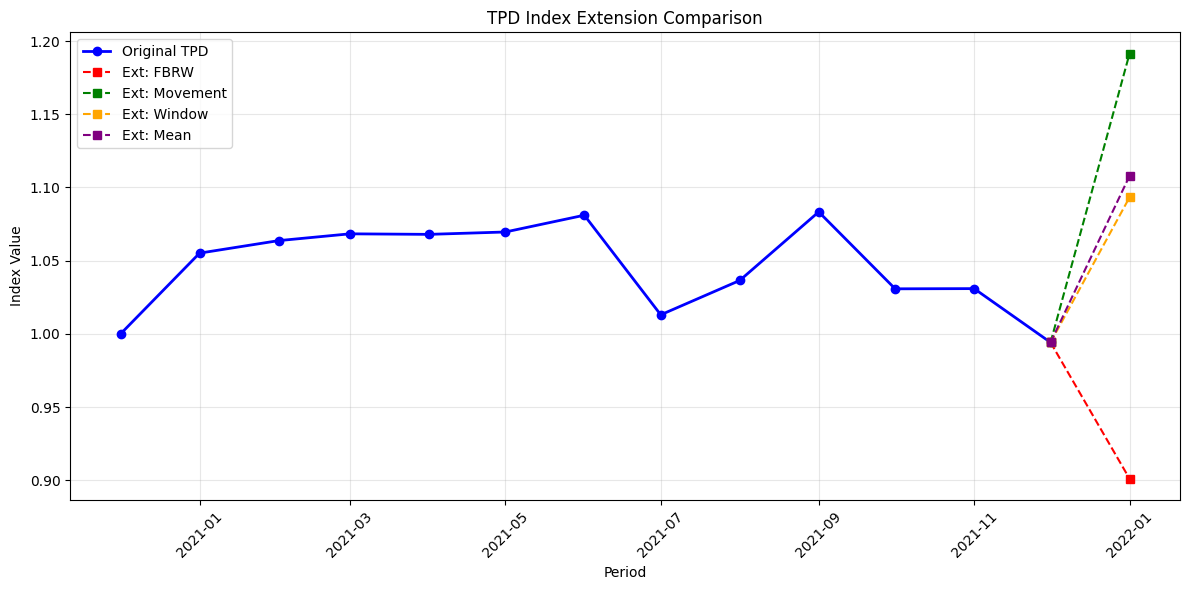

In [ ]:
import matplotlib.pyplot as plt

# Prepare historical data (up to 2021-12-01)
history = tpd_index
last_date = history["period"].max()
last_val = history.filter(pl.col("period") == last_date)["index_value"][0]

# Extract the extensions for 2022-01-01
ext_date = extension_comparison["period"][4]

plt.figure(figsize=(12, 6))

# Plot original series
plt.plot(history["period"], history["index_value"], label='Original TPD', color='blue', linewidth=2, marker='o')

# Define extensions to plot from the last historical point
extensions = [
    ('FBRW', extension_comparison["FBRW"][4], 'red'),
    ('Movement', extension_comparison["Movement"][4], 'green'),
    ('Window', extension_comparison["Window"][4], 'orange'),
    ('Mean', extension_comparison["Mean"][4], 'purple')
]

# Plot each extension as a segment from the last known point
for label, val, color in extensions:
    plt.plot([last_date, ext_date], [last_val, val], color=color, linestyle='--', marker='s', label=f'Ext: {label}')

plt.title('TPD Index Extension Comparison')
plt.xlabel('Period')
plt.ylabel('Index Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()